# 连续 Label 主线 Layer Probe

主目标是 `residual_signed_raw` 与 `delta_log_dispersion` 在 Layer 0～12 的信息演化、关联和可解码性。固定头路径按当前协议锁定为 `CLS → fc`，属于用户锁定假设，不代表已考证原训练架构。旧情绪主线产物不在本 Notebook 中读取。

In [1]:
import sys

from pathlib import Path
import json
import os
import pandas as pd
from IPython.display import display

CONFIGURED_ROOT = os.environ.get('CHINESE_WWM_ROBERTA_ROOT')
ROOT_CANDIDATES = [
    Path(CONFIGURED_ROOT).expanduser() if CONFIGURED_ROOT else None,
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path.home() / 'Projects' / 'chinese-wwm-roberta',
]
ROOT = next((path.resolve() for path in ROOT_CANDIDATES if path is not None and (path / 'configs' / 'layer_probe.yaml').is_file()), None)
assert ROOT is not None, '找不到项目根目录；请设置CHINESE_WWM_ROBERTA_ROOT或确认~/Projects/chinese-wwm-roberta存在'
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from src.layer_probe_representations import plot_representation_layer_norms, run_representation_stage, resolve_representation_directory, validate_representation_artifacts
from src.layer_probe_continuous import (align_continuous_targets, plot_aligned_target_counts, plot_continuous_probe_curves, plot_fixed_head_convergence, plot_fixed_head_label_associations, run_continuous_probe_stage, run_fixed_head_analysis_stage, run_fixed_head_label_stage, validate_aligned_targets, validate_continuous_probe_outputs, validate_fixed_head_analysis_outputs, validate_fixed_head_label_outputs)
from src.layer_probe_models import plot_optional_sentiment_curve, run_optional_sentiment_probe_stage, run_return_probe_stage, validate_optional_sentiment_outputs
from src.layer_probe_panel import plot_stock_day_summary, run_stock_day_panel_stage, validate_stock_day_artifacts
from src.layer_probe_factors import run_factor_validation_stage
from src.layer_probe_pipeline import (assert_preflight, load_layer_probe_config, plot_factor_summary, plot_return_curve, preflight_report, run_final_test_once, validate_factor_outputs, validate_pipeline_outputs, validate_return_probe_outputs)

CONFIG_PATH = ROOT / 'configs' / 'layer_probe.yaml'
config = load_layer_probe_config(CONFIG_PATH)
RUN_DIR = Path(config['output']['run_directory']).expanduser().resolve()
pd.set_option('display.max_columns', 100)
print('repo:', ROOT)
print('run:', RUN_DIR)

repo: /home/intern_fjq_2026/Projects/chinese-wwm-roberta
run: /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/continuous_label_layer_probe/runs/main_v2


## 0. 执行开关

已有且通过manifest验收的阶段应把对应开关设为 `False`。最终test与情绪附录默认关闭。

In [2]:
RUN_STAGE_1_REPRESENTATIONS = True
RUN_STAGE_2A_FIXED_HEAD = True
RUN_STAGE_2A_PLUS_ASSOCIATION = True
RUN_STAGE_2B_CONTINUOUS_PROBE = True
RUN_STAGE_3_STOCK_DAY = True
RUN_STAGE_4_RETURN_PROBE = True
RUN_STAGE_5_6_FACTOR_VALIDATION = True
RUN_FINAL_TEST_CELL = False
RUN_SENTIMENT_APPENDIX = False

if RUN_FINAL_TEST_CELL:
    assert config['strict_test']['open_final_test'] is True
else:
    assert config['strict_test']['open_final_test'] is False
if RUN_SENTIMENT_APPENDIX:
    assert config['sentiment_appendix']['enabled'] is True

## 1. 一次 backbone forward 提取 Layer 0～12

本阶段不检查任何Label、收益或时间切分。Layer 12投影必须与锁定的normal forward数值一致。

,stage,check,status,blocking,detail
0,representation,text.path,ok,True,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
1,representation,model.checkpoint,ok,True,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
2,representation,model.base_model_dir,ok,True,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
3,representation,model.head_recipe,ok,True,cls_fc (provenance=user_locked_assumption; his...
4,representation,legacy_artifact_isolation,ok,True,run=/home/intern_fjq_2026/Projects/chinese-wwm...
5,representation,gpu_mapping,ok,True,"{""requested_device"": ""cuda:1"", ""cuda"": true, ""..."
6,representation,cpu_thread_budget,ok,True,"{""configured_threads"": 8, ""effective_threads"":..."
7,representation,disk_peak_estimate,ok,True,filesystem=/home/intern_fjq_2026/Projects/chin...
8,representation,disk_inventory,ok,False,"{""text_input_bytes"": 169744165, ""model_cache_b..."


rows                                                                      93731
layers                                                                       13
hidden_size                                                                 768
dtype                                                                   float16
fixed_head_rows                                                         1218503
representation_fingerprint    02153fb541a3aa1134e26a270f0f41a11cf64b6143b1f3...
head_recipe                                                              cls_fc
head_provenance                                          user_locked_assumption
Name: representation_validation, dtype: object

passed                 True
rtol                  0.001
atol                  0.001
max_absolute_error      0.0
max_relative_error      0.0
dtype: object

analysis_name                                                  frozen_cls_fc_projection
recipe                                                                           cls_fc
provenance                                                       user_locked_assumption
historical_training_path_confirmed                                                False
interpretation                        Layer 12 equivalence validates implementation ...
dtype: object

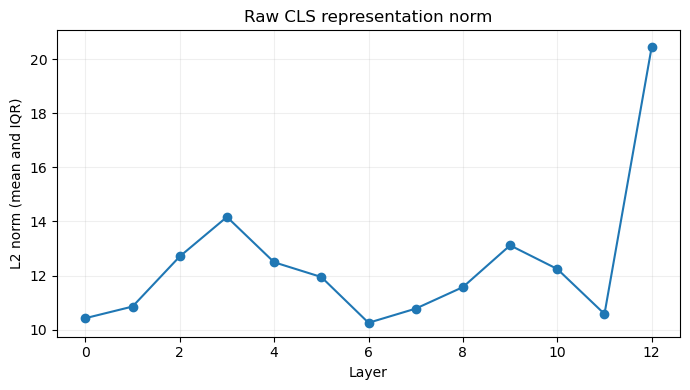

In [3]:
representation_preflight = preflight_report(config, stages=['representation'])
display(representation_preflight)
assert_preflight(representation_preflight)
if RUN_STAGE_1_REPRESENTATIONS:
    run_representation_stage(config)
representation_directory = resolve_representation_directory(config)
representation_check = validate_representation_artifacts(representation_directory)
display(pd.Series(representation_check, name='representation_validation'))
representation_manifest = json.loads((representation_directory / 'representation_manifest.json').read_text(encoding='utf-8'))
display(pd.Series(representation_manifest['layer12_equivalence']))
plot_representation_layer_norms(representation_directory);
display(pd.Series(representation_manifest['head_contract']))
assert representation_manifest['layer12_equivalence']['passed'] is True

## 2A. 无Label固定CLS-fc逐层投影

这里只分析分布、饱和、相邻层变化、类别翻转以及向最终方向的收敛，不比较‘最佳层’。

,stage,check,status,blocking,detail
0,fixed_head,representation_and_layer12,ok,True,"{'rows': 93731, 'layers': 13, 'hidden_size': 7..."
1,fixed_head,historical_head_provenance,warning,False,"CLS->fc is a user-locked assumption, not histo..."


layers         13
transitions    12
dtype: int64

,layer,n,class_0_logit_mean,class_0_logit_std,class_1_logit_mean,class_1_logit_std,margin_mean,margin_std,class_0_probability_mean,class_0_probability_std,class_1_probability_mean,class_1_probability_std,probability_entropy_mean,class_0_logit_q01,class_0_logit_q05,class_0_logit_q25,class_0_logit_q50,class_0_logit_q75,class_0_logit_q95,class_0_logit_q99,class_1_logit_q01,class_1_logit_q05,class_1_logit_q25,class_1_logit_q50,class_1_logit_q75,class_1_logit_q95,class_1_logit_q99,margin_q01,margin_q05,margin_q25,margin_q50,margin_q75,margin_q95,margin_q99,class_0_probability_q01,class_0_probability_q05,class_0_probability_q25,class_0_probability_q50,class_0_probability_q75,class_0_probability_q95,class_0_probability_q99,class_1_probability_q01,class_1_probability_q05,class_1_probability_q25,class_1_probability_q50,class_1_probability_q75,class_1_probability_q95,class_1_probability_q99,max_probability_ge_90,max_probability_ge_95,max_probability_ge_99
0,0,93731,-0.086731,0.000068,0.200562,0.000042,0.287293,0.000004,0.428711,0.000000,0.571289,0.000000,0.682948,-0.086731,-0.086731,-0.086731,-0.086731,-0.086731,-0.086731,-0.086731,0.200562,0.200562,0.200562,0.200562,0.200562,0.200562,0.200562,0.287292,0.287292,0.287292,0.287292,0.287292,0.287292,0.287292,0.428711,0.428711,0.428711,0.428711,0.428711,0.428711,0.428711,0.571289,0.571289,0.571289,0.571289,0.571289,0.571289,0.571289,0.000000,0.0,0.0
1,1,93731,0.201092,0.011503,0.069551,0.010294,-0.131540,0.007365,0.532836,0.001837,0.467166,0.001833,0.690982,0.162598,0.180176,0.196289,0.203857,0.208618,0.215210,0.220337,0.044464,0.047211,0.066772,0.072327,0.076172,0.081787,0.086792,-0.147827,-0.142700,-0.136719,-0.131958,-0.127014,-0.118713,-0.111694,0.527832,0.529785,0.531738,0.532715,0.534180,0.535645,0.537109,0.463135,0.464355,0.465820,0.467041,0.468262,0.470459,0.472168,0.000000,0.0,0.0
2,2,93731,0.406072,0.006861,0.004936,0.004974,-0.401136,0.007152,0.598964,0.001720,0.401042,0.001722,0.673423,0.388184,0.391602,0.402832,0.407471,0.410645,0.415039,0.417969,-0.005985,-0.003664,0.001790,0.004826,0.007942,0.013443,0.017944,-0.415162,-0.411557,-0.406042,-0.401896,-0.396927,-0.388191,-0.380595,0.594238,0.595703,0.598145,0.599121,0.600098,0.601562,0.602539,0.397705,0.398438,0.399902,0.400879,0.402100,0.404053,0.406006,0.000000,0.0,0.0
3,3,93731,0.536167,0.003947,0.010403,0.003510,-0.525764,0.005298,0.628494,0.001245,0.371506,0.001240,0.659749,0.528320,0.530273,0.533203,0.535645,0.539062,0.543457,0.545898,0.004704,0.006233,0.008415,0.009949,0.011658,0.014862,0.026917,-0.536476,-0.533525,-0.529388,-0.526138,-0.522827,-0.517441,-0.507359,0.624023,0.626465,0.627930,0.628418,0.629395,0.630371,0.630859,0.368896,0.369629,0.370605,0.371338,0.372070,0.373535,0.375732,0.000000,0.0,0.0
4,4,93731,0.477623,0.004296,0.004325,0.003621,-0.473299,0.006483,0.616159,0.001531,0.383835,0.001539,0.665909,0.467773,0.472412,0.475098,0.476807,0.479004,0.486816,0.489990,-0.004859,-0.001147,0.002256,0.004124,0.006340,0.010544,0.014702,-0.491314,-0.485466,-0.475576,-0.472551,-0.469936,-0.465302,-0.453369,0.611328,0.614258,0.615234,0.616211,0.616699,0.619141,0.620605,0.379639,0.380859,0.383301,0.384033,0.384521,0.385742,0.388672,0.000000,0.0,0.0
5,5,93731,0.459211,0.001989,0.011337,0.001605,-0.447874,0.002954,0.610135,0.000726,0.389865,0.000715,0.668687,0.454590,0.457031,0.458252,0.458984,0.459717,0.463135,0.465820,0.007198,0.008678,0.010368,0.011322,0.012367,0.013969,0.015015,-0.458622,-0.453110,-0.448845,-0.447594,-0.446388,-0.444054,-0.440804,0.608398,0.609375,0.609863,0.609863,0.610352,0.611328,0.612793,0.387207,0.388672,0.389648,0.389893,0.390137,0.390869,0.391602,0.000000,0.0,0.0
6,6,93731,0.399628,0.001029,0.017408,0.001324,-0.382220,0.001965,0.594410,0.000492,0.405591,0.000482,0.675212,0.395996,0.398193,0.399170,0.399658,0.400146,0.401367,0.401855,0.014030,0.014496,0.017105,0.017776,0.018265,0.018936,0.019440,-0.387360,-0.386299,-0.382996,-0.381775,-0.380951,-0.379700,-0.378571,0.593750,0.593750,0.594238,0.594238,

,from_layer,to_layer,class_0_logit_delta_mean,class_0_logit_delta_abs_mean,class_1_logit_delta_mean,class_1_logit_delta_abs_mean,margin_delta_mean,margin_delta_abs_mean,probability_delta_mean,probability_delta_abs_mean,class_flip_rate
0,0,1,0.287822,0.287822,-0.131010,0.131010,-0.418833,0.418833,-0.104123,0.104123,1.000000
1,1,2,0.204980,0.204980,-0.064615,0.064615,-0.269596,0.269596,-0.066124,0.066124,0.000000
2,2,3,0.130095,0.130095,0.005467,0.006486,-0.124628,0.124628,-0.029535,0.029535,0.000000
3,3,4,-0.058543,0.058543,-0.006078,0.006186,0.052465,0.052465,0.012329,0.012329,0.000000
4,4,5,-0.018412,0.018412,0.007012,0.007083,0.025425,0.025425,0.006030,0.006030,0.000000
5,5,6,-0.059583,0.059583,0.006071,0.006073,0.065654,0.065654,0.015726,0.015726,0.000000
6,6,7,0.035170,0.035170,-0.012831,0.012831,-0.048001,0.048001,-0.011518,0.011518,0.000000
7,7,8,0.015753,0.015753,-0.015260,0.015260,-0.031014,0.031014,-0.007381,0.007381,0.000000
8,8,9,0.043474,0.043474,-0.026174,0.026174,-0.069648,0.069648,-0.016381,0.016381,0.000000
9,9,10,-0.051098,0.051098,-0.013594,0.013594,0.037503,0.037503,0.008784,0.008784,0.000000


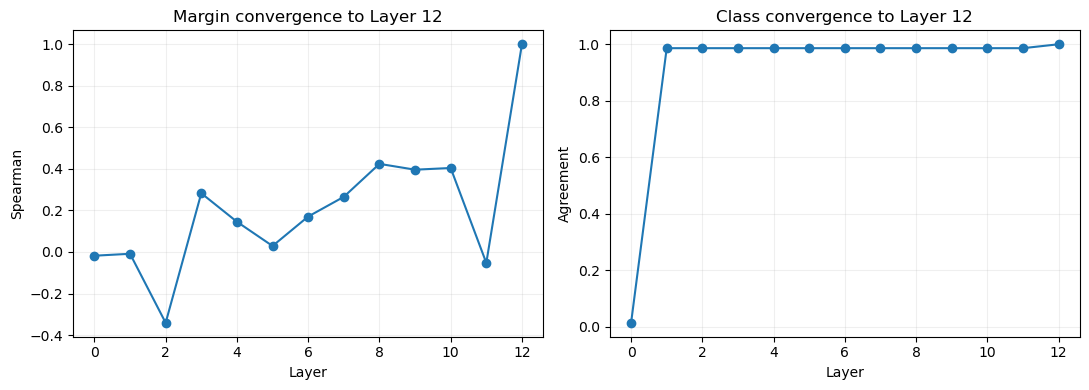

In [4]:
head_preflight = preflight_report(config, stages=['fixed_head'])
display(head_preflight)
assert_preflight(head_preflight)
if RUN_STAGE_2A_FIXED_HEAD:
    run_fixed_head_analysis_stage(config)
fixed_head_dir = RUN_DIR / 'fixed_head_analysis'
display(pd.Series(validate_fixed_head_analysis_outputs(fixed_head_dir)))
display(pd.read_csv(fixed_head_dir / 'fixed_head_layer_distributions.csv'))
display(pd.read_csv(fixed_head_dir / 'fixed_head_adjacent_transitions.csv'))
plot_fixed_head_convergence(fixed_head_dir);

## 2A+. 固定头输出与连续Label的关系

不训练参数。所有结果按task、层和split独立计算，validation分组边界只由train固定头输出确定。

,stage,check,status,blocking,detail
0,continuous_labels,probe_targets,ok,True,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
1,continuous_labels,probe_dataset_metadata,ok,True,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
2,continuous_labels,probe_merge_audit,ok,True,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
3,continuous_labels,report_task_unique,ok,True,True
4,continuous_labels,chronological_splits,ok,True,"[{'name': 'train', 'feature_start': '2024-01-0..."
5,continuous_labels,label_available_date,ok,True,valid=265232/265232
6,continuous_labels,upstream_label_provenance,ok,True,report_fy_labels.parquet + report_confirmation...


rows                   265232
tasks                      18
splits    [train, validation]
dtype: object

metric_rows    234
tasks            9
dtype: int64

,task_id,label_name,layer,split,prediction_role,forecast_horizon,confirmation_months,peer_panel,n,effective_n,weight_sum,spearman,pearson,direction_n,zero_or_tie_n,class_1_margin_direction_accuracy
1,delta_log_dispersion__1m__active__fh0,delta_log_dispersion,0,validation,oos,0,1,active,6563,6563,5994.881618,NaN,NaN,6396,167,0.441995
3,delta_log_dispersion__1m__active__fh0,delta_log_dispersion,1,validation,oos,0,1,active,6563,6563,5994.881618,0.020383,0.023114,6396,167,0.558005
5,delta_log_dispersion__1m__active__fh0,delta_log_dispersion,2,validation,oos,0,1,active,6563,6563,5994.881618,0.000302,-0.010054,6396,167,0.558005
7,delta_log_dispersion__1m__active__fh0,delta_log_dispersion,3,validation,oos,0,1,active,6563,6563,5994.881618,-0.013355,-0.008959,6396,167,0.558005
9,delta_log_dispersion__1m__active__fh0,delta_log_dispersion,4,validation,oos,0,1,active,6563,6563,5994.881618,-0.009753,0.010425,6396,167,0.558005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,delta_log_dispersion__1m__market__fh2,delta_log_dispersion,8,validation,oos,2,1,market,7701,6841,6401.865777,0.024450,0.013841,6777,924,0.430574
227,delta_log_dispersion__1m__market__fh2,delta_log_dispersion,9,validation,oos,2,1,market,7701,6841,6401.865777,-0.010233,-0.012784,6777,924,0.430574
229,delta_log_dispersion__1m__market__fh2,delta_log_dispersion,10,validation,oos,2,1,market,7701,6841,6401.865777,0.044724,0.031472,6777,924,0.430574
231,delta_log_dispersion__1m__market__fh2,delta_log_dispersion,11,validation,oos,2,1,market,7701,6841,6401.865777,0.079032,0.105310,6777,924,0.430574


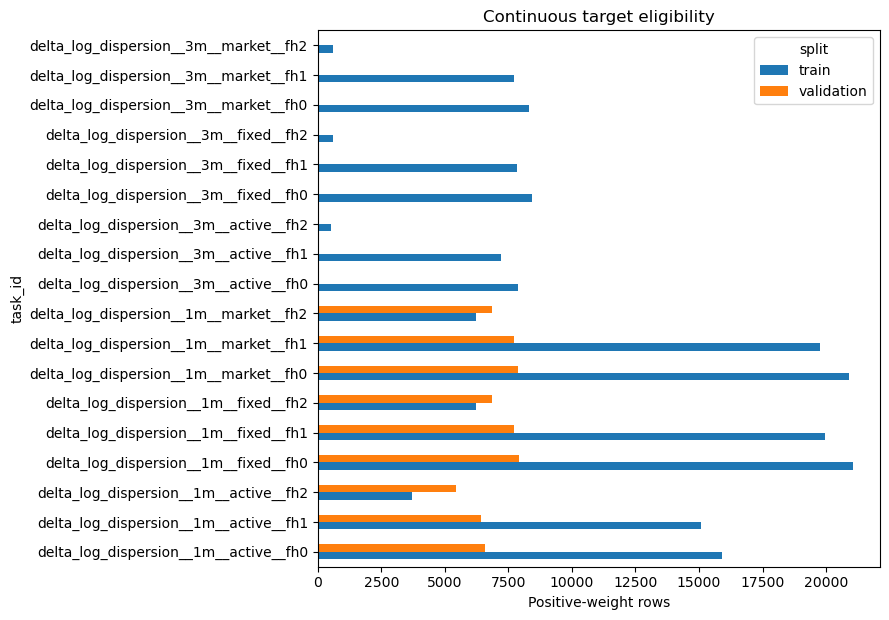

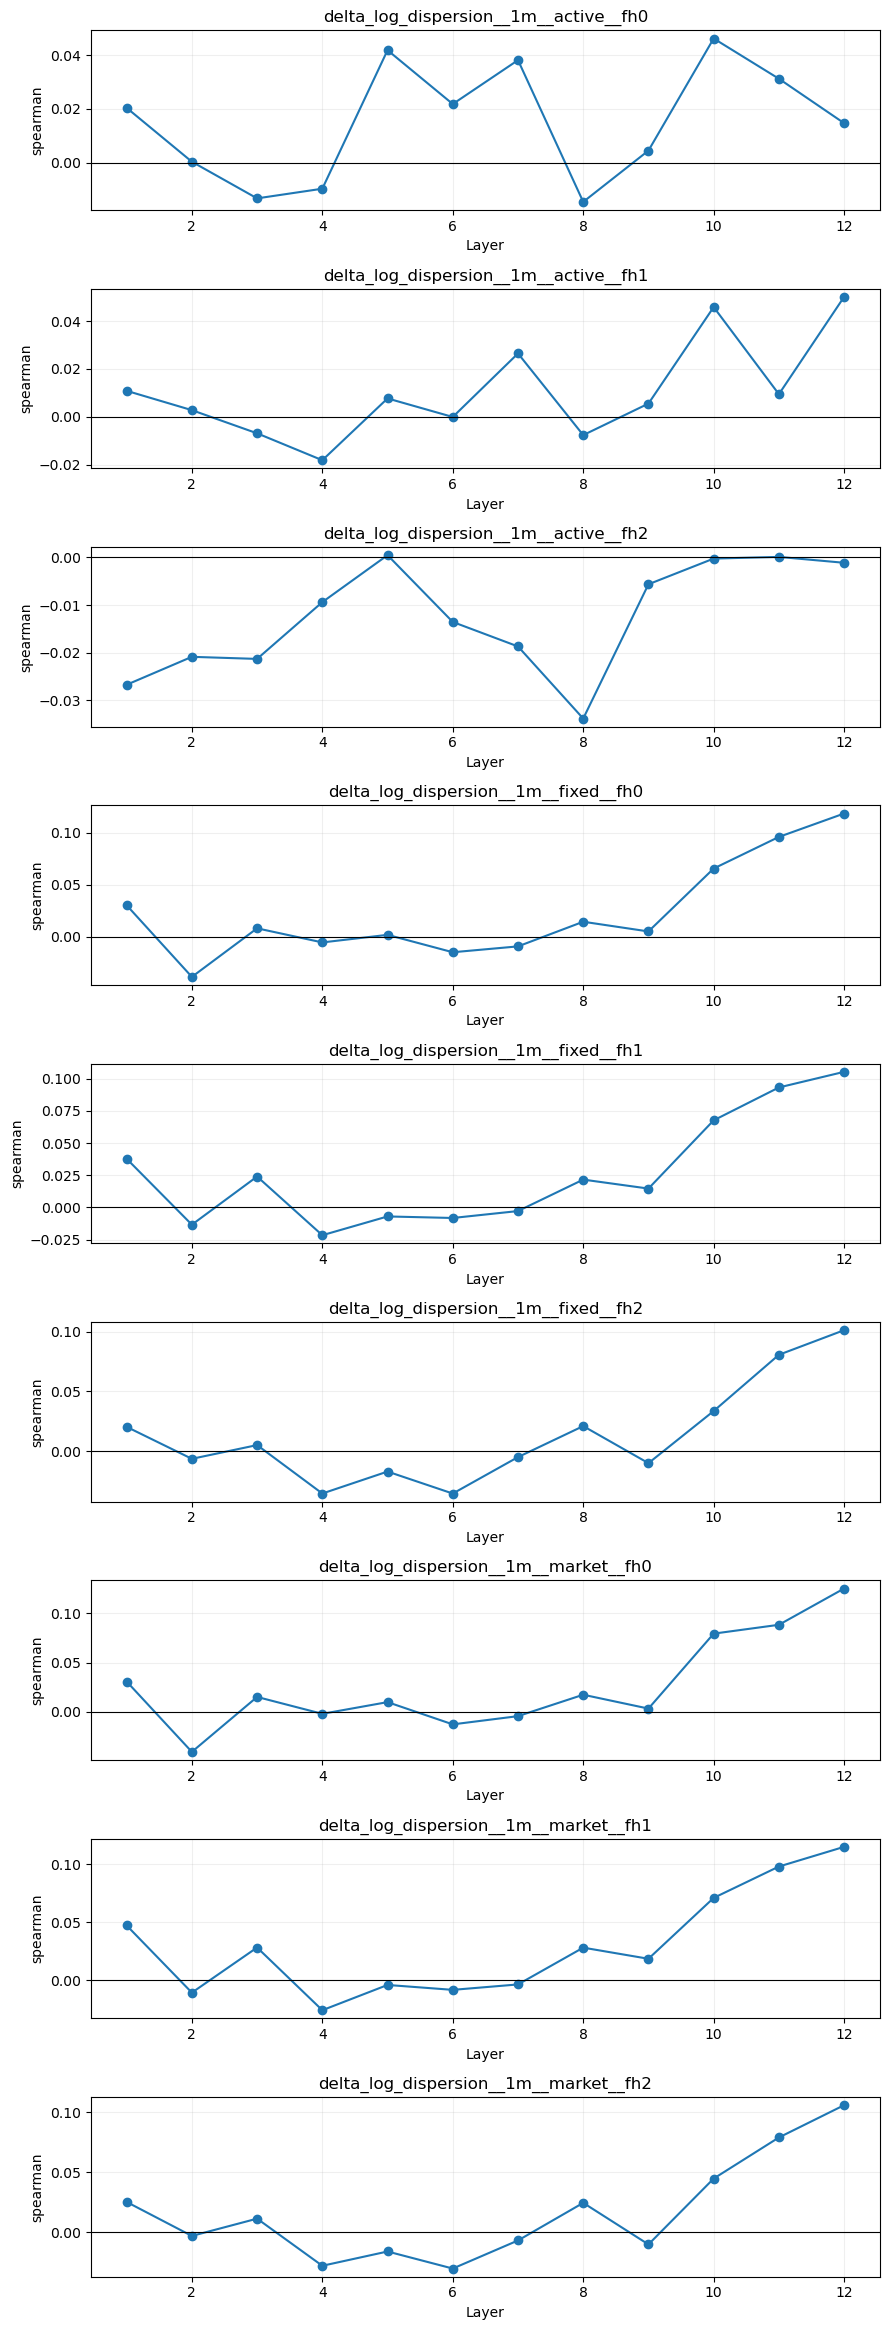

In [5]:
continuous_preflight = preflight_report(config, stages=['continuous_labels'])
display(continuous_preflight)
assert_preflight(continuous_preflight)
aligned_target_dir = align_continuous_targets(config)
display(pd.Series(validate_aligned_targets(aligned_target_dir)))
if RUN_STAGE_2A_PLUS_ASSOCIATION:
    run_fixed_head_label_stage(config, evaluation_split='validation')
association_dir = RUN_DIR / 'fixed_head_label' / 'validation'
display(pd.Series(validate_fixed_head_label_outputs(association_dir)))
association_metrics = pd.read_csv(association_dir / 'fixed_head_label_metrics.csv')
display(association_metrics[association_metrics['prediction_role'].eq('oos')].sort_values(['task_id', 'layer']))
plot_aligned_target_counts(aligned_target_dir);
plot_fixed_head_label_associations(association_dir);

## 2B. 连续Label逐层Ridge Probe

每个task和layer独立拟合weighted StandardScaler与Ridge；validation只由train拟合，test前按冻结alpha在train+validation重拟合。

/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.60891e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=5.47374e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=3.89223e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=8.44092e-09): result may not be accurate.
  return lina

metric_rows           216
oos_rows           760728
reference_rows    1545636
tasks                   9
dtype: int64

,task_id,label_name,layer,split,prediction_role,selected_alpha,n,weight_sum,spearman,pearson,r2,mae,rmse,weighted_r2,weighted_mae,weighted_rmse,sign_n,sign_accuracy
1,delta_log_dispersion__1m__active__fh0,delta_log_dispersion,1,validation,oos,1000.0,6563,5994.881618,-0.058206,-0.045026,-0.064139,0.867747,1.455327,-0.071382,0.837116,1.384765,6396,0.542527
3,delta_log_dispersion__1m__active__fh0,delta_log_dispersion,2,validation,oos,100.0,6563,5994.881618,-0.015580,-0.011554,-0.088156,0.895021,1.471659,-0.098946,0.865278,1.402465,6396,0.539712
5,delta_log_dispersion__1m__active__fh0,delta_log_dispersion,3,validation,oos,0.1,6563,5994.881618,0.001840,0.005157,-0.108941,0.911853,1.485648,-0.121604,0.882321,1.416849,6396,0.529393
7,delta_log_dispersion__1m__active__fh0,delta_log_dispersion,4,validation,oos,10.0,6563,5994.881618,-0.022680,-0.003868,-0.082760,0.892779,1.468005,-0.093766,0.863036,1.399155,6396,0.530644
9,delta_log_dispersion__1m__active__fh0,delta_log_dispersion,5,validation,oos,1.0,6563,5994.881618,-0.016919,-0.013893,-0.107415,0.906714,1.484625,-0.119959,0.877138,1.415809,6396,0.521732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,delta_log_dispersion__1m__market__fh2,delta_log_dispersion,8,validation,oos,0.1,6841,6401.865777,-0.051774,-0.041192,-0.235834,0.374899,0.534077,-0.250557,0.372747,0.523282,6403,0.486491
209,delta_log_dispersion__1m__market__fh2,delta_log_dispersion,9,validation,oos,100.0,6841,6401.865777,-0.037937,-0.038242,-0.126767,0.346562,0.509966,-0.133365,0.344722,0.498160,6403,0.493987
211,delta_log_dispersion__1m__market__fh2,delta_log_dispersion,10,validation,oos,0.1,6841,6401.865777,-0.035476,-0.035173,-0.180951,0.363722,0.522083,-0.190566,0.361941,0.510577,6403,0.504295
213,delta_log_dispersion__1m__market__fh2,delta_log_dispersion,11,validation,oos,1000.0,6841,6401.865777,-0.025756,-0.034502,-0.082613,0.334119,0.499874,-0.087046,0.332629,0.487875,6403,0.500547


,record_type,task_id,evaluation_split,scope,reason,count,training_rows,evaluation_rows,eligible,layer
0,exclusion_audit,delta_log_dispersion__1m__active__fh0,validation,training,nonfinite_label,0.0,NaN,NaN,NaN,NaN
1,exclusion_audit,delta_log_dispersion__1m__active__fh0,validation,training,nonfinite_weight,0.0,NaN,NaN,NaN,NaN
2,exclusion_audit,delta_log_dispersion__1m__active__fh0,validation,training,nonpositive_weight,0.0,NaN,NaN,NaN,NaN
3,exclusion_audit,delta_log_dispersion__1m__active__fh0,validation,evaluation,nonfinite_label,0.0,NaN,NaN,NaN,NaN
4,exclusion_audit,delta_log_dispersion__1m__active__fh0,validation,evaluation,nonfinite_weight,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
130,exclusion_audit,delta_log_dispersion__3m__market__fh2,validation,training,nonpositive_weight,7.0,NaN,NaN,NaN,NaN
131,exclusion_audit,delta_log_dispersion__3m__market__fh2,validation,evaluation,nonfinite_label,0.0,NaN,NaN,NaN,NaN
132,exclusion_audit,delta_log_dispersion__3m__market__fh2,validation,evaluation,nonfinite_weight,0.0,NaN,NaN,NaN,NaN
133,exclusion_audit,delta_log_dispersion__3m__market__fh2,validation,evaluation,nonpositive_weight,0.0,NaN,NaN,NaN,NaN


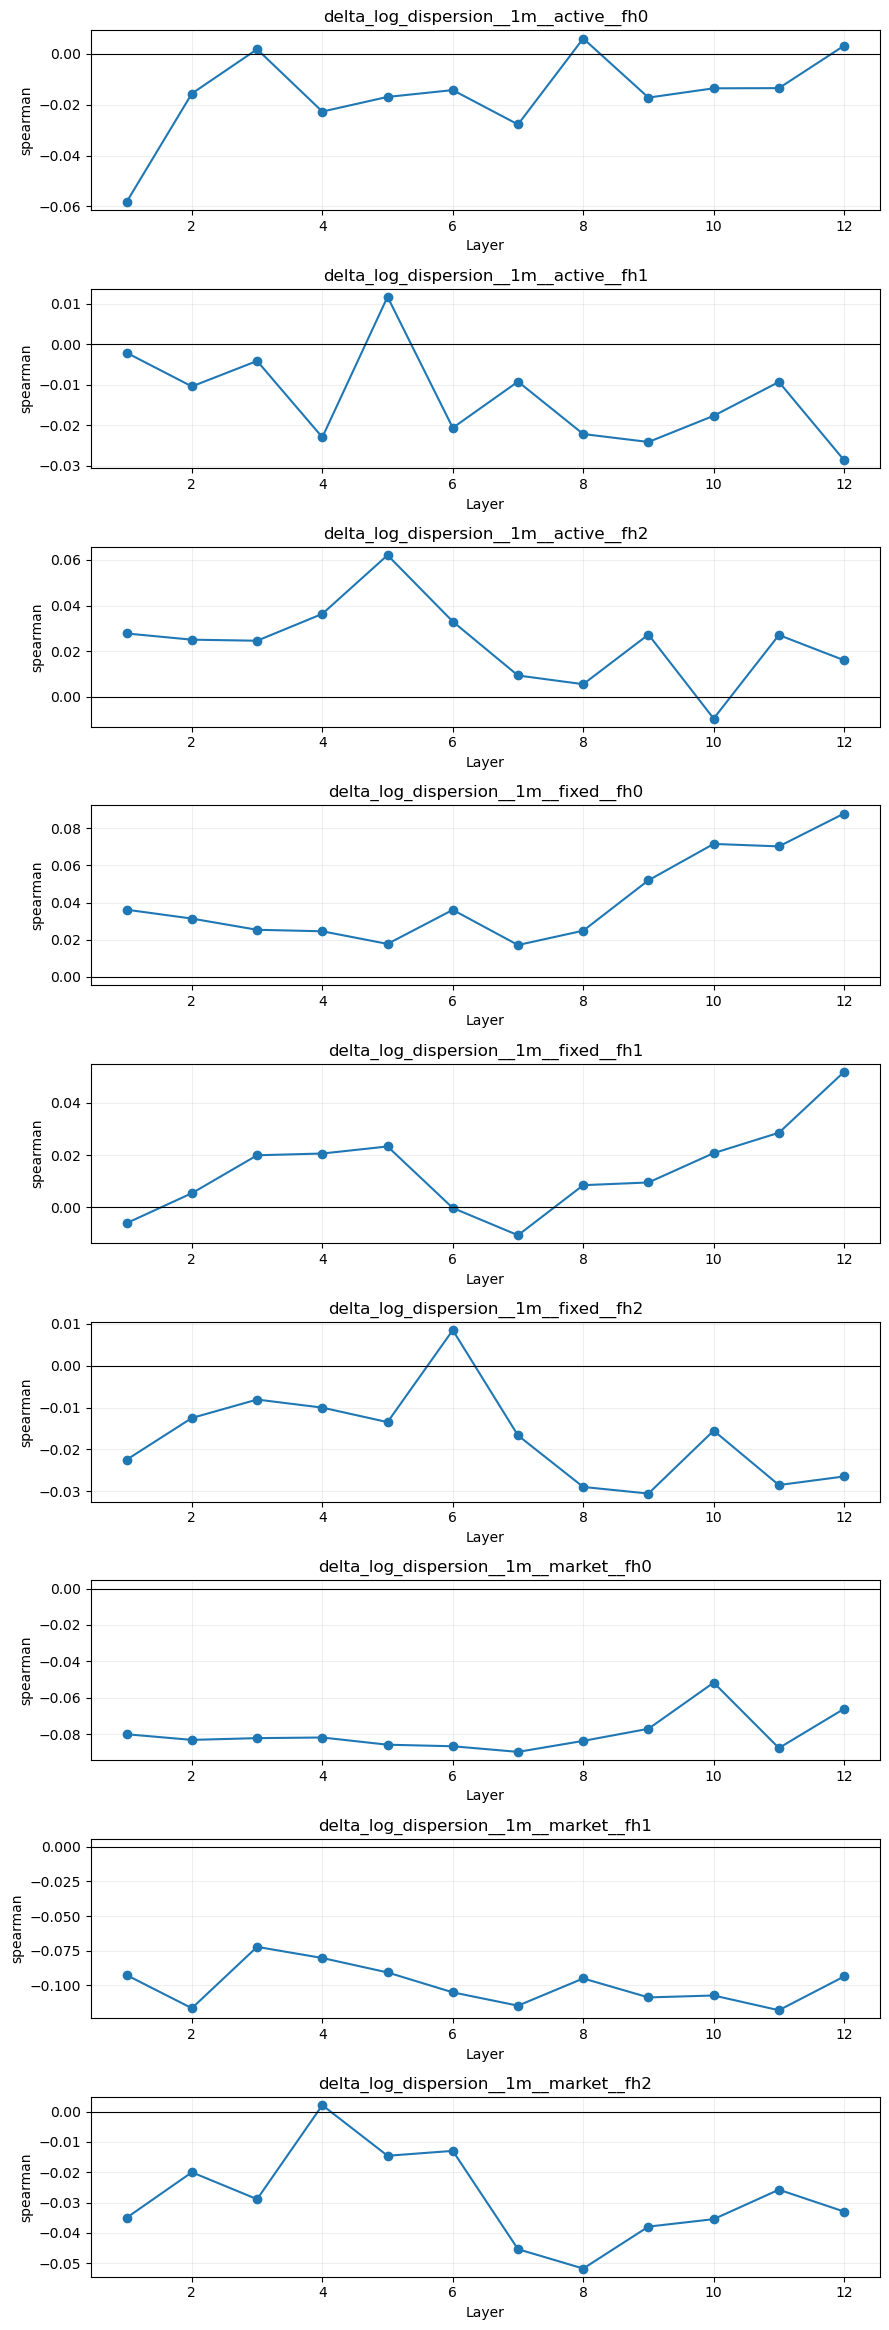

In [6]:
if RUN_STAGE_2B_CONTINUOUS_PROBE:
    run_continuous_probe_stage(config, evaluation_split='validation')
continuous_probe_dir = RUN_DIR / 'continuous_probe' / 'validation'
display(pd.Series(validate_continuous_probe_outputs(continuous_probe_dir)))
continuous_metrics = pd.read_csv(continuous_probe_dir / 'continuous_probe_metrics.csv')
display(continuous_metrics[continuous_metrics['prediction_role'].eq('oos')].sort_values(['task_id', 'layer']))
display(pd.read_csv(continuous_probe_dir / 'continuous_probe_eligibility.csv'))
plot_continuous_probe_curves(continuous_probe_dir, metric='spearman');

## 3. 股票日Representation与未来收益

按symbol × trading_date聚合13层，保存n_texts，连接未来1/5/20日行业调整收益并执行最长窗口purge。

,stage,check,status,blocking,detail
0,returns,industry_adjusted_daily_path,ok,True,/home/intern_fjq_2026/data/target/target_close...
1,returns,return_time_splits,ok,True,train:2024-01-01~2024-06-30; validation:2024-0...
2,returns,exposures.industry_path,invalid,False,/home/intern_fjq_2026/data/barra/Barra_Industr...
3,returns,exposures.size_path,invalid,False,/home/intern_fjq_2026/data/barra/Barra_SIZE.h5


[info] target_close_spret.h5 percentiles: 9.0900 > 1.00, scaling /100


canonical_rows                                     56562
evaluation_rows                                    32954
layers                                                13
hidden_size                                          768
evaluation_split                              validation
split_counts        {'train': 23870, 'validation': 9084}
dtype: object

,rows,dates,symbols,mean_texts
split,,,,
train,23870,97,2926,1.713238
validation,9084,44,2262,1.841259


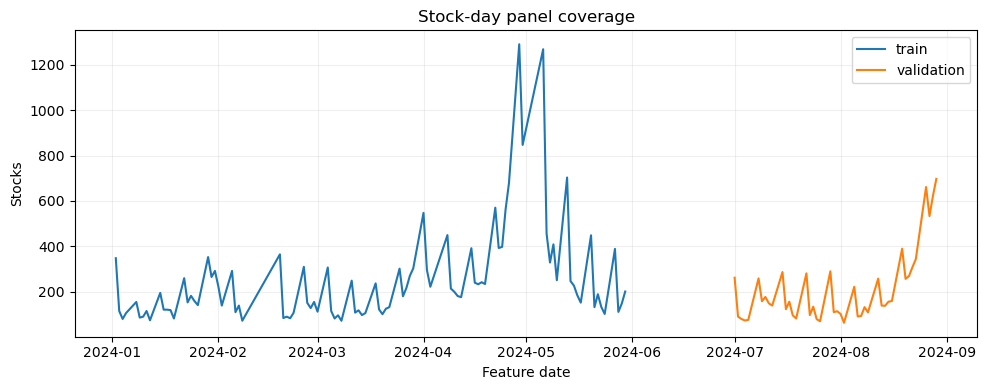

In [7]:
return_preflight = preflight_report(config, stages=['returns'])
display(return_preflight)
assert_preflight(return_preflight)
if RUN_STAGE_3_STOCK_DAY:
    run_stock_day_panel_stage(config, evaluation_split='validation')
stock_day_dir = RUN_DIR / 'stock_day_panel'
display(pd.Series(validate_stock_day_artifacts(stock_day_dir, evaluation_split='validation')))
stock_day_panel = pd.read_parquet(stock_day_dir / 'validation' / 'stock_day_panel.parquet')
display(stock_day_panel.groupby('split').agg(rows=('representation_row', 'size'), dates=('trading_date', 'nunique'), symbols=('symbol', 'nunique'), mean_texts=('n_texts', 'mean')))
plot_stock_day_summary(stock_day_dir, evaluation_split='validation');

## 4. 逐层收益Ridge Probe（validation）

/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.89e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=3.50023e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.68896e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=4.92656e-08): result may not be accurate.
  return linalg.

metric_rows           13
oos_rows          114764
reference_rows    305604
dtype: int64

,layer,split,selected_alpha,rank_ic,ic_std,icir,t_stat,positive_fraction,n_days,icir_annualized
0,0,validation,1000.0,NaN,NaN,NaN,NaN,NaN,0,NaN
1,1,validation,1000.0,0.047922,0.090985,0.526706,3.493771,0.681818,44,8.361195
2,2,validation,100.0,0.049955,0.091726,0.544607,3.612515,0.704545,44,8.645370
3,3,validation,1000.0,0.053150,0.107812,0.492991,3.270131,0.681818,44,7.825987
4,4,validation,100.0,0.059707,0.108695,0.549313,3.643727,0.727273,44,8.720067
5,5,validation,1000.0,0.054814,0.095515,0.573876,3.806662,0.727273,44,9.109998
6,6,validation,1000.0,0.064076,0.098047,0.653527,4.335008,0.727273,44,10.374420
7,7,validation,1000.0,0.074525,0.101965,0.730888,4.848164,0.840909,44,11.602491
8,8,validation,1000.0,0.069610,0.104816,0.664120,4.405275,0.750000,44,10.542580
9,9,validation,1000.0,0.109591,0.098583,1.111659,7.373914,0.909091,44,17.647045


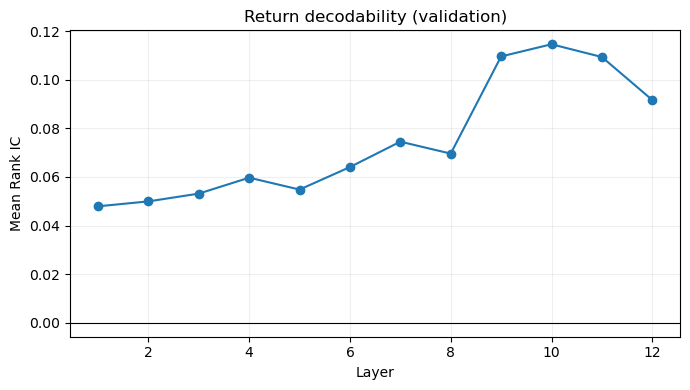

In [8]:
if RUN_STAGE_4_RETURN_PROBE:
    run_return_probe_stage(config, evaluation_split='validation')
return_probe_dir = RUN_DIR / 'return_probe' / 'validation'
display(pd.Series(validate_return_probe_outputs(return_probe_dir)))
display(pd.read_csv(return_probe_dir / 'return_probe_metrics.csv').sort_values(['split', 'layer']))
plot_return_curve(return_probe_dir, split='validation');

## 5～6. 跨层因子与严格validation检验

包含单层、共识、分歧、deep-minus-middle、deep residual和PCA；增量IC控制fixed_head_margin与log1p(n_texts)。

rows                 8828
candidate_factors      20
evaluated              20
dtype: int64

,factor,hac_t_stat,hac_pvalue,hac_lags,rank_ic,ic_std,icir,t_stat,positive_fraction,n_days,icir_annualized,qvalue_bh
10,single_layer_10,7.108163,1.175973e-12,4,0.114602,0.103988,1.102067,7.310285,0.931818,44,17.494769,7.447830e-12
9,single_layer_9,8.054302,7.993379e-16,4,0.109591,0.098583,1.111659,7.373914,0.909091,44,17.647045,7.593710e-15
11,single_layer_11,4.705289,2.535063e-06,4,0.109353,0.112211,0.974532,6.464317,0.886364,44,15.470222,6.020775e-06
13,layer_consensus,5.923867,3.144585e-09,4,0.098082,0.112420,0.872461,5.787253,0.863636,44,13.849892,1.194942e-08
17,layer_pca_1,5.826328,5.666013e-09,4,0.097400,0.111580,0.872912,5.790246,0.863636,44,13.857056,1.794238e-08
12,single_layer_12,3.615410,2.998728e-04,4,0.091662,0.123695,0.741028,4.915423,0.818182,44,11.763454,4.420081e-04
15,deep_minus_middle,4.094263,4.235132e-05,4,0.085635,0.116649,0.734126,4.869640,0.772727,44,11.653887,8.046751e-05
18,layer_pca_2,4.365607,1.267700e-05,4,0.081455,0.098100,0.830323,5.507739,0.840909,44,13.180967,2.676255e-05
7,single_layer_7,8.646904,5.291565e-18,4,0.074525,0.101965,0.730888,4.848164,0.840909,44,11.602491,1.005397e-16
8,single_layer_8,6.141295,8.185154e-10,4,0.069610,0.104816,0.664120,4.405275,0.750000,44,10.542580,3.887948e-09


,factor,quantiles,monotonic_spearman,top_minus_bottom_mean,top_minus_bottom_hac_t,top_minus_bottom_hac_pvalue,hac_lags,n_days
0,deep_minus_middle,5,1.0,0.014074,4.137510,0.000035,4,44
1,deep_residual,5,0.9,0.010269,2.259680,0.023841,4,44
2,layer_consensus,5,0.9,0.013853,4.265529,0.000020,4,44
3,layer_disagreement,5,0.7,0.003756,1.564680,0.117658,4,44
4,layer_pca_1,5,0.9,0.014069,4.284611,0.000018,4,44
5,layer_pca_2,5,1.0,0.012355,3.423711,0.000618,4,44
6,layer_pca_3,5,0.7,0.004488,1.222870,0.221379,4,44
7,single_layer_1,5,0.7,0.006337,3.020966,0.002520,4,44
8,single_layer_10,5,1.0,0.016431,4.443539,0.000009,4,44
9,single_layer_11,5,1.0,0.017022,3.516200,0.000438,4,44


,factor,hac_t_stat,hac_pvalue,hac_lags,rank_ic,ic_std,icir,t_stat,positive_fraction,n_days,qvalue_bh
0,single_layer_0,-0.422653,6.725487e-01,4,-0.002772,0.053990,-0.051340,-0.290425,0.562500,32,6.725487e-01
1,single_layer_1,2.446910,1.440869e-02,4,0.037210,0.090535,0.411001,2.726271,0.613636,44,1.921159e-02
2,single_layer_2,2.822118,4.770759e-03,4,0.037662,0.092815,0.405771,2.691578,0.681818,44,6.815370e-03
3,single_layer_3,2.274592,2.293042e-02,4,0.042748,0.101758,0.420092,2.786578,0.659091,44,2.697697e-02
4,single_layer_4,3.227510,1.248725e-03,4,0.049216,0.114479,0.429913,2.851722,0.704545,44,2.081208e-03
5,single_layer_5,2.959880,3.077591e-03,4,0.043847,0.096626,0.453774,3.009999,0.727273,44,4.734755e-03
6,single_layer_6,5.046707,4.494896e-07,4,0.054149,0.100941,0.536446,3.558379,0.613636,44,1.284256e-06
7,single_layer_7,7.237141,4.582412e-13,4,0.063363,0.101915,0.621723,4.124047,0.818182,44,4.545299e-12
8,single_layer_8,5.797103,6.747016e-09,4,0.061091,0.110452,0.553097,3.668830,0.750000,44,3.373508e-08
9,single_layer_9,7.239556,4.501555e-13,4,0.093845,0.098897,0.948916,6.294399,0.909091,44,4.545299e-12


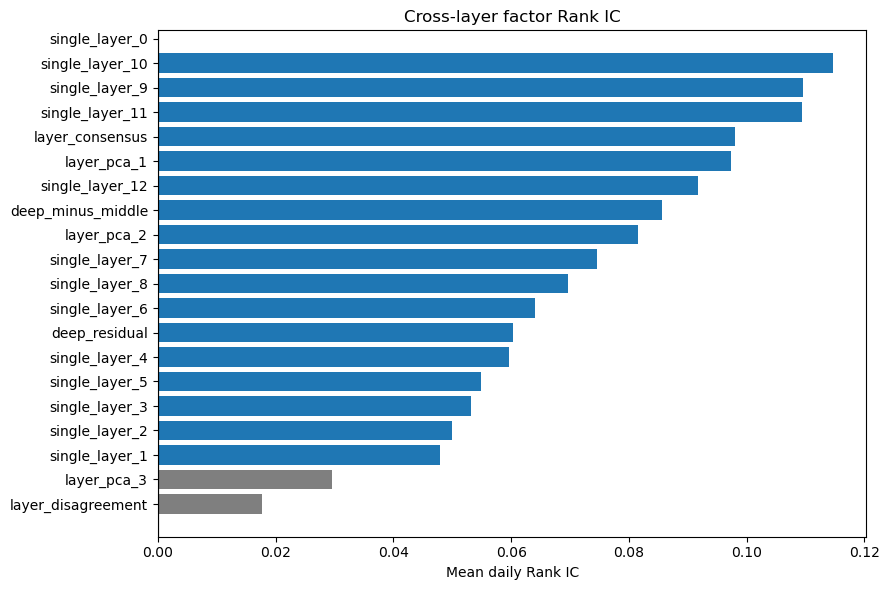

In [9]:
if RUN_STAGE_5_6_FACTOR_VALIDATION:
    run_factor_validation_stage(config, evaluation_split='validation')
factor_dir = RUN_DIR / 'factor_validation' / 'validation'
display(pd.Series(validate_factor_outputs(factor_dir)))
factor_summary = pd.read_csv(factor_dir / 'factor_summary.csv').sort_values('rank_ic', ascending=False)
display(factor_summary)
display(pd.read_csv(factor_dir / 'quantile_monotonicity.csv'))
display(pd.read_csv(factor_dir / 'incremental_ic.csv'))
plot_factor_summary(factor_dir);

## Validation后预注册

在打开最终test前，将保留因子写入 `strict_test.selected_factors`，冻结validation manifest和决策规则。

In [10]:
candidate_columns = pd.read_parquet(factor_dir / 'candidate_factor_matrix.parquet').columns
candidate_names = [name for name in candidate_columns if name.startswith('single_layer_') or name in {'layer_consensus', 'layer_disagreement', 'deep_minus_middle', 'deep_residual'} or name.startswith('layer_pca_')]
display(pd.Series(candidate_names, name='可预注册因子'))

0         single_layer_0
1         single_layer_1
2         single_layer_2
3         single_layer_3
4         single_layer_4
5         single_layer_5
6         single_layer_6
7         single_layer_7
8         single_layer_8
9         single_layer_9
10       single_layer_10
11       single_layer_11
12       single_layer_12
13       layer_consensus
14    layer_disagreement
15     deep_minus_middle
16         deep_residual
17           layer_pca_1
18           layer_pca_2
19           layer_pca_3
Name: 可预注册因子, dtype: object

## 最终test：只打开一次

只有在validation完成、因子预注册、配置中 `strict_test.open_final_test: true` 且下方开关为True时执行。marker创建后不得重跑或调参。

In [11]:
if RUN_FINAL_TEST_CELL:
    final_config = load_layer_probe_config(CONFIG_PATH)
    strict_preflight = preflight_report(final_config, stages=['strict_test'])
    display(strict_preflight)
    assert_preflight(strict_preflight)
    display(run_final_test_once(final_config))
else:
    print('最终test保持关闭。')

最终test保持关闭。


## 附录：可选0/1情绪Probe

本附录默认关闭，只有显式启用且确认类别映射后才检查sentiment_label；其缺失不影响任何主阶段。

In [12]:
sentiment_preflight = preflight_report(config, stages=['sentiment_appendix'])
display(sentiment_preflight)
if RUN_SENTIMENT_APPENDIX:
    assert config['sentiment_appendix']['enabled'] is True
    assert_preflight(sentiment_preflight)
    sentiment_dir = run_optional_sentiment_probe_stage(config)
    display(pd.Series(validate_optional_sentiment_outputs(sentiment_dir)))
    plot_optional_sentiment_curve(sentiment_dir);
else:
    print('情绪附录保持关闭。')

,stage,check,status,blocking,detail
0,sentiment_appendix,enabled,ok,False,disabled


情绪附录保持关闭。


## 全管线验收

In [13]:
pipeline_validation = validate_pipeline_outputs(config)
display(pipeline_validation)
assert not pipeline_validation['status'].eq('failed').any()

,stage,status,detail
0,representations,ok,"{""rows"": 93731, ""layers"": 13, ""hidden_size"": 7..."
1,fixed_head_analysis,ok,"{""layers"": 13, ""transitions"": 12}"
2,continuous_targets,ok,"{""rows"": 265232, ""tasks"": 18, ""splits"": [""trai..."
3,fixed_head_label_validation,ok,"{""metric_rows"": 234, ""tasks"": 9}"
4,continuous_probe_validation,ok,"{""metric_rows"": 216, ""oos_rows"": 760728, ""refe..."
5,stock_day_panel,ok,"{""canonical_rows"": 56562, ""evaluation_rows"": 3..."
6,return_probe_validation,ok,"{""metric_rows"": 13, ""oos_rows"": 114764, ""refer..."
7,factor_validation,ok,"{""rows"": 8828, ""candidate_factors"": 20, ""evalu..."
